# 🧠 The Self-Pruning Neural Network

**Case Study — Tredence Analytics AI Engineering Internship**

---

## Overview

This notebook implements a neural network that **learns to prune itself during training**. Instead of removing weights post-training, the network uses learnable "gate" parameters to dynamically identify and zero-out unnecessary connections.

### Key Components
1. **`PrunableLinear` Layer** — Custom linear layer with per-weight learnable gates
2. **Sparsity Regularization** — L1 penalty on gate values to encourage pruning
3. **Multi-λ Experiment** — Comparing sparsity vs. accuracy trade-off across different regularization strengths

### Dataset
- **CIFAR-10** — 60,000 32×32 color images across 10 classes

### Runtime
- **GPU**: T4 (Runtime → Change runtime type → T4 GPU)

---
*Author: Vaibhav*  
*Date: April 2026*

## 1. Environment Setup & Imports

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import OrderedDict
import time
import copy
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'

# ── Device Configuration ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.mem_get_info(0)[1] / 1e9:.1f} GB")


Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Data Loading — CIFAR-10

We apply standard data augmentation:
- **Training**: Random horizontal flip + random crop (with padding) + normalization
- **Testing**: Normalization only

In [40]:
# ── CIFAR-10 Statistics ──
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# ── Transforms ──
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# ── Download & Load Datasets ──
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# ── DataLoaders ──
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Training batches:   {len(train_loader)}")


Training samples:   50,000
Test samples:       10,000
Batch size:         256
Training batches:   196


---

## 3. Part 1 — The `PrunableLinear` Layer

This is the core innovation. Each weight $w_{ij}$ is multiplied by a learnable gate $g_{ij}$:

$$g_{ij} = \sigma(s_{ij})$$

$$\tilde{w}_{ij} = w_{ij} \cdot g_{ij}$$

where $s_{ij}$ is a learnable gate score and $\sigma$ is the sigmoid function.

**Key Design Decisions:**
- `gate_scores` are initialized to **+2.0** so that $\sigma(2) \approx 0.88$, keeping all gates mostly open at the start. This lets the network learn normally before the sparsity pressure takes effect.
- Weights are initialized with **Kaiming Uniform** (standard for ReLU networks).
- The forward pass uses `F.linear()` with the pruned weights, ensuring clean autograd flow.

In [41]:
class PrunableLinear(nn.Module):
    """
    A custom linear layer with per-weight learnable gates for self-pruning.

    Each weight w_ij has an associated gate score s_ij. During the forward pass:
        1. Gates are computed:        g = sigmoid(gate_scores)
        2. Weights are pruned:        pruned_w = weight * g
        3. Linear transform applied:  output = input @ pruned_w^T + bias

    The gate scores are learnable parameters updated by the optimizer,
    and the sparsity loss (L1 on gate values) drives unused gates to zero.

    Args:
        in_features (int):  Number of input features.
        out_features (int): Number of output features.
    """

    def __init__(self, in_features: int, out_features: int):
        super(PrunableLinear, self).__init__()

        self.in_features = in_features
        self.out_features = out_features

        # ── Standard weight and bias parameters ──
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))

        # ── Learnable gate scores (same shape as weight) ──
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        self._initialize_parameters()

    def _initialize_parameters(self):
        """Initialize weights (Kaiming) and gate scores (starting at 0.5)."""
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

        fan_in = self.in_features
        bound = 1.0 / np.sqrt(fan_in)
        nn.init.uniform_(self.bias, -bound, bound)

        # Gate scores initialized to 0.0 → sigmoid(0) = 0.5
        # Starting at 0.5 means:
        #   - Sigmoid gradient is MAXIMAL here (0.25), enabling fast learning
        #   - Gates can be pushed toward 0 (prune) or 1 (keep) equally easily
        #   - Symmetry is broken by classification gradients
        nn.init.constant_(self.gate_scores, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        output = F.linear(x, pruned_weights, self.bias)
        return output

    def get_gate_values(self) -> torch.Tensor:
        with torch.no_grad():
            return torch.sigmoid(self.gate_scores).detach()

    def get_sparsity(self, threshold: float = 1e-2) -> float:
        gates = self.get_gate_values()
        num_pruned = (gates < threshold).sum().item()
        total = gates.numel()
        return (num_pruned / total) * 100.0

    def extra_repr(self) -> str:
        return f'in_features={self.in_features}, out_features={self.out_features}'


# ── Quick Sanity Check ──
test_layer = PrunableLinear(10, 5)
test_input = torch.randn(3, 10)
test_output = test_layer(test_input)
print(f"PrunableLinear created: (10 → 5)")
print(f"  Weight shape:      {test_layer.weight.shape}")
print(f"  Gate scores shape: {test_layer.gate_scores.shape}")
print(f"  Output shape:      {test_output.shape}")
print(f"  Initial gate mean: {test_layer.get_gate_values().mean():.4f}  (should be ~0.50)")
print(f"  Gradients flow:    weight={test_layer.weight.requires_grad}, "
      f"gates={test_layer.gate_scores.requires_grad}")
print("\n✅ PrunableLinear layer is working correctly!")


PrunableLinear created: (10 → 5)
  Weight shape:      torch.Size([5, 10])
  Gate scores shape: torch.Size([5, 10])
  Output shape:      torch.Size([3, 5])
  Initial gate mean: 0.5000  (should be ~0.50)
  Gradients flow:    weight=True, gates=True

✅ PrunableLinear layer is working correctly!


### Gradient Flow Verification

We must ensure that gradients flow correctly through **both** `weight` and `gate_scores`. Let's verify this with a simple backward pass.

In [42]:
# ── Gradient Flow Test ──
layer = PrunableLinear(4, 3)
x = torch.randn(2, 4)
target = torch.tensor([0, 1])

# Forward + backward
output = layer(x)
loss = F.cross_entropy(output, target)
loss.backward()

print("Gradient Flow Verification:")
print(f"  weight.grad:      shape={layer.weight.grad.shape}, "
      f"non-zero={layer.weight.grad.abs().sum() > 0}")
print(f"  gate_scores.grad: shape={layer.gate_scores.grad.shape}, "
      f"non-zero={layer.gate_scores.grad.abs().sum() > 0}")
print(f"  bias.grad:        shape={layer.bias.grad.shape}, "
      f"non-zero={layer.bias.grad.abs().sum() > 0}")
print("\n✅ Gradients flow correctly through all parameters!")

Gradient Flow Verification:
  weight.grad:      shape=torch.Size([3, 4]), non-zero=True
  gate_scores.grad: shape=torch.Size([3, 4]), non-zero=True
  bias.grad:        shape=torch.Size([3]), non-zero=True

✅ Gradients flow correctly through all parameters!


---

## 4. The Self-Pruning Network Architecture

A feed-forward MLP using `PrunableLinear` layers:

```
Input (3×32×32 = 3072) → Flatten
  → PrunableLinear(3072, 1024) → BatchNorm → ReLU
  → PrunableLinear(1024, 512)  → BatchNorm → ReLU
  → PrunableLinear(512, 256)   → BatchNorm → ReLU
  → PrunableLinear(256, 10)    → Output (logits)
```

**BatchNorm** is included between layers for training stability — as gates suppress connections, BatchNorm helps re-normalize activations to prevent training collapse.

In [43]:
class SelfPruningNetwork(nn.Module):
    """
    A feed-forward neural network that prunes itself during training.
    Architecture: 3072 → 1024 → 512 → 256 → 10
    """

    def __init__(self):
        super(SelfPruningNetwork, self).__init__()
        self.fc1 = PrunableLinear(3 * 32 * 32, 1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.fc3 = PrunableLinear(512, 256)
        self.fc4 = PrunableLinear(256, 10)
        self.bn1 = nn.BatchNorm1d(1024)
        self.bn2 = nn.BatchNorm1d(512)
        self.bn3 = nn.BatchNorm1d(256)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x

    def get_all_prunable_layers(self) -> list:
        return [m for m in self.modules() if isinstance(m, PrunableLinear)]

    def compute_sparsity_loss(self) -> torch.Tensor:
        """
        L1 sparsity loss = SUM of all gate values across all layers.
        Using SUM (not mean) so lambda directly controls total penalty.
        """
        sparsity_loss = torch.tensor(0.0, device=next(self.parameters()).device)
        for layer in self.get_all_prunable_layers():
            gates = torch.sigmoid(layer.gate_scores)
            sparsity_loss = sparsity_loss + gates.sum()
        return sparsity_loss

    def get_overall_sparsity(self, threshold: float = 1e-2) -> float:
        total_params = 0
        pruned_params = 0
        for layer in self.get_all_prunable_layers():
            gates = layer.get_gate_values()
            total_params += gates.numel()
            pruned_params += (gates < threshold).sum().item()
        return (pruned_params / total_params) * 100.0 if total_params > 0 else 0.0

    def get_layer_sparsity_report(self, threshold: float = 1e-2) -> dict:
        report = {}
        for name, module in self.named_modules():
            if isinstance(module, PrunableLinear):
                report[name] = {
                    'sparsity': module.get_sparsity(threshold),
                    'shape': f'{module.in_features}→{module.out_features}',
                    'total_weights': module.weight.numel(),
                    'pruned_weights': int((module.get_gate_values() < threshold).sum().item()),
                    'gate_mean': module.get_gate_values().mean().item(),
                }
        return report

    def get_all_gate_values(self) -> np.ndarray:
        all_gates = []
        for layer in self.get_all_prunable_layers():
            all_gates.append(layer.get_gate_values().cpu().numpy().flatten())
        return np.concatenate(all_gates)


# ── Model Summary ──
model = SelfPruningNetwork().to(device)
total_params = sum(p.numel() for p in model.parameters())
gate_params = sum(l.gate_scores.numel() for l in model.get_all_prunable_layers())
print(f"Total params: {total_params:,} | Gate params: {gate_params:,}")
del model


Total params: 7,612,682 | Gate params: 3,803,648


---

## 5. Part 2 — Training Utilities

### Loss Function

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \cdot \mathcal{L}_{\text{sparsity}}$$

- $\mathcal{L}_{\text{CE}}$: Standard cross-entropy classification loss
- $\mathcal{L}_{\text{sparsity}}$: L1 norm of all gate values (sum of all $\sigma(s_{ij})$)
- $\lambda$: Hyperparameter controlling the pruning aggressiveness

In [44]:
def train_one_epoch(model, train_loader, optimizer, criterion, lam, device):
    """
    Train the model for one epoch with sparsity regularization.

    Args:
        model:        SelfPruningNetwork instance
        train_loader: DataLoader for training data
        optimizer:    Optimizer (e.g., Adam)
        criterion:    Classification loss function (e.g., CrossEntropyLoss)
        lam:          Lambda — sparsity regularization strength
        device:       torch device

    Returns:
        Dictionary with epoch metrics:
            avg_total_loss, avg_ce_loss, avg_sparsity_loss, accuracy, sparsity
    """
    model.train()

    running_total_loss = 0.0
    running_ce_loss = 0.0
    running_sparsity_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # ── Forward Pass ──
        outputs = model(images)

        # ── Compute Total Loss ──
        # 1. Classification loss (Cross-Entropy)
        ce_loss = criterion(outputs, labels)

        # 2. Sparsity regularization loss (L1 on gate values)
        sparsity_loss = model.compute_sparsity_loss()

        # 3. Total loss = CE + λ * Sparsity
        total_loss = ce_loss + lam * sparsity_loss

        # ── Backward Pass & Optimize ──
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # ── Track Metrics ──
        running_total_loss += total_loss.item()
        running_ce_loss += ce_loss.item()
        running_sparsity_loss += sparsity_loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    num_batches = len(train_loader)
    return {
        'avg_total_loss': running_total_loss / num_batches,
        'avg_ce_loss': running_ce_loss / num_batches,
        'avg_sparsity_loss': running_sparsity_loss / num_batches,
        'accuracy': 100.0 * correct / total,
        'sparsity': model.get_overall_sparsity(),
    }


@torch.no_grad()
def evaluate(model, test_loader, criterion, device):
    """
    Evaluate the model on the test set.

    Args:
        model:       SelfPruningNetwork instance
        test_loader: DataLoader for test data
        criterion:   Classification loss function
        device:      torch device

    Returns:
        Dictionary with test_loss and test_accuracy.
    """
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return {
        'test_loss': running_loss / len(test_loader),
        'test_accuracy': 100.0 * correct / total,
    }


print("✅ Training utilities defined.")

✅ Training utilities defined.


---

## 6. Part 3 — Training & Multi-λ Experiment

We train the network with **three different λ values** to demonstrate the sparsity-accuracy trade-off:

| λ Value | Expected Behavior |
|---------|-------------------|
| `1e-5` (Low) | Minimal pruning, highest accuracy |
| `1e-4` (Medium) | Moderate pruning, slight accuracy drop |
| `1e-3` (High) | Aggressive pruning, noticeable accuracy drop |

Each model trains for **35 epochs** with the Adam optimizer.

In [45]:
def run_experiment(lam, num_epochs=40, lr=1e-3, gate_lr=0.01, warmup_epochs=10):
    """
    Train with lambda warmup: first learn what's important, then prune.
      - Epochs 1 to warmup_epochs: λ = 0 (pure classification)
      - Epochs warmup+1 to end: λ ramps linearly from 0 to target
    """
    print(f"\n{'═' * 70}")
    print(f"  EXPERIMENT: λ = {lam}")
    print(f"  Epochs: {num_epochs} | Weight LR: {lr} | Gate LR: {gate_lr}")
    print(f"  Warmup: {warmup_epochs} epochs (λ=0), then ramp to λ={lam}")
    print(f"{'═' * 70}")

    model = SelfPruningNetwork().to(device)
    criterion = nn.CrossEntropyLoss()

    # ── Separate parameter groups ──
    gate_params = []
    other_params = []
    for name, param in model.named_parameters():
        if 'gate_scores' in name:
            gate_params.append(param)
        else:
            other_params.append(param)

    optimizer = optim.Adam([
        {'params': other_params, 'lr': lr},
        {'params': gate_params, 'lr': gate_lr},
    ])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        'train_loss': [], 'ce_loss': [], 'sparsity_loss': [],
        'train_acc': [], 'test_acc': [], 'sparsity': [],
    }

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        # ── Lambda warmup schedule ──
        if epoch <= warmup_epochs:
            current_lam = 0.0  # No pruning during warmup
        else:
            # Linear ramp from 0 to lam over remaining epochs
            progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
            current_lam = lam * progress

        train_metrics = train_one_epoch(
            model, train_loader, optimizer, criterion, current_lam, device
        )
        test_metrics = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_metrics['avg_total_loss'])
        history['ce_loss'].append(train_metrics['avg_ce_loss'])
        history['sparsity_loss'].append(train_metrics['avg_sparsity_loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['test_acc'].append(test_metrics['test_accuracy'])
        history['sparsity'].append(train_metrics['sparsity'])

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  Epoch {epoch:>3}/{num_epochs} │ "
                f"CE: {train_metrics['avg_ce_loss']:.4f} │ "
                f"λ_eff: {current_lam:.2e} │ "
                f"Train Acc: {train_metrics['accuracy']:.1f}% │ "
                f"Test Acc: {test_metrics['test_accuracy']:.1f}% │ "
                f"Pruned: {train_metrics['sparsity']:.1f}% │ "
                f"Gate Mean: {model.get_all_gate_values().mean():.4f}"
            )

    elapsed = time.time() - start_time
    final_test = evaluate(model, test_loader, criterion, device)
    final_sparsity = model.get_overall_sparsity()

    print(f"\n  ── Final Results for λ = {lam} ──")
    print(f"  Test Accuracy:    {final_test['test_accuracy']:.2f}%")
    print(f"  Overall Sparsity: {final_sparsity:.2f}%")
    print(f"  Training Time:    {elapsed:.1f}s ({elapsed/60:.1f} min)")

    print(f"\n  ── Per-Layer Sparsity Breakdown ──")
    layer_report = model.get_layer_sparsity_report()
    for name, info in layer_report.items():
        print(
            f"    {name:>4} ({info['shape']:>12}): "
            f"sparsity={info['sparsity']:6.2f}% | "
            f"pruned={info['pruned_weights']:>8,}/{info['total_weights']:>8,} | "
            f"gate_mean={info['gate_mean']:.4f}"
        )

    return model, history, final_test['test_accuracy'], final_sparsity


print("✅ Experiment runner defined.")


✅ Experiment runner defined.


### Run All Three Experiments

Training 3 models sequentially with different λ values. Each takes ~3-4 minutes on T4 GPU.

In [46]:
LAMBDA_VALUES = [1e-5, 1e-4, 5e-4]  # Low, Medium, High
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3

results = {}

for lam in LAMBDA_VALUES:
    model, history, test_acc, sparsity = run_experiment(
        lam=lam, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
        gate_lr=0.01, warmup_epochs=10
    )
    results[lam] = {
        'model': model,
        'history': history,
        'test_accuracy': test_acc,
        'sparsity': sparsity,
    }

print("\n" + "═" * 70)
print("  ALL EXPERIMENTS COMPLETE!")
print("═" * 70)



══════════════════════════════════════════════════════════════════════
  EXPERIMENT: λ = 1e-05
  Epochs: 40 | Weight LR: 0.001 | Gate LR: 0.01
  Warmup: 10 epochs (λ=0), then ramp to λ=1e-05
══════════════════════════════════════════════════════════════════════
  Epoch   1/40 │ CE: 1.7677 │ λ_eff: 0.00e+00 │ Train Acc: 35.9% │ Test Acc: 43.8% │ Pruned: 0.0% │ Gate Mean: 0.4966
  Epoch   5/40 │ CE: 1.3882 │ λ_eff: 0.00e+00 │ Train Acc: 50.0% │ Test Acc: 53.2% │ Pruned: 0.0% │ Gate Mean: 0.4803
  Epoch  10/40 │ CE: 1.2486 │ λ_eff: 0.00e+00 │ Train Acc: 55.0% │ Test Acc: 57.7% │ Pruned: 0.0% │ Gate Mean: 0.4624
  Epoch  15/40 │ CE: 1.1274 │ λ_eff: 1.67e-06 │ Train Acc: 59.7% │ Test Acc: 60.3% │ Pruned: 0.4% │ Gate Mean: 0.1983
  Epoch  20/40 │ CE: 1.0407 │ λ_eff: 3.33e-06 │ Train Acc: 62.6% │ Test Acc: 61.7% │ Pruned: 18.0% │ Gate Mean: 0.1101
  Epoch  25/40 │ CE: 0.9862 │ λ_eff: 5.00e-06 │ Train Acc: 64.6% │ Test Acc: 63.2% │ Pruned: 36.4% │ Gate Mean: 0.0788
  Epoch  30/40 │ CE: 0.9418

In [58]:
import zipfile
import os
from google.colab import files

result_files = [
    'training_curves.png',
    'gate_distributions_all.png',
    'gate_distribution.png',
    'sparsity_vs_accuracy.png',
    'metrics.json',
    'results_table.csv',
]

zip_name = 'self_pruning_results.zip'
with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in result_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✅ Added: {f}")
        else:
            print(f"  ⚠️ Missing: {f}")

print(f"\n📦 Created: {zip_name}")
files.download(zip_name)


  ✅ Added: training_curves.png
  ✅ Added: gate_distributions_all.png
  ✅ Added: gate_distribution.png
  ✅ Added: sparsity_vs_accuracy.png
  ✅ Added: metrics.json
  ✅ Added: results_table.csv

📦 Created: self_pruning_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
# ══════════════════════════════════════════════════════════════
#  SAVE ALL METRICS TO FILE
# ══════════════════════════════════════════════════════════════
import json
import csv

# ── 1. Save detailed metrics as JSON ──
metrics = {}
for lam in LAMBDA_VALUES:
    r = results[lam]
    model = r['model']
    layer_report = model.get_layer_sparsity_report()

    metrics[str(lam)] = {
        'test_accuracy': r['test_accuracy'],
        'overall_sparsity': r['sparsity'],
        'per_layer': {
            name: {
                'shape': info['shape'],
                'sparsity': round(info['sparsity'], 2),
                'pruned_weights': info['pruned_weights'],
                'total_weights': info['total_weights'],
                'gate_mean': round(info['gate_mean'], 4),
            }
            for name, info in layer_report.items()
        },
        'training_history': {
            'ce_loss': r['history']['ce_loss'],
            'test_acc': r['history']['test_acc'],
            'sparsity': r['history']['sparsity'],
        }
    }

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✅ Saved: metrics.json")

# ── 2. Save results table as CSV ──
with open('results_table.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Lambda', 'Test Accuracy (%)', 'Sparsity Level (%)'])
    for lam in LAMBDA_VALUES:
        r = results[lam]
        writer.writerow([lam, round(r['test_accuracy'], 2), round(r['sparsity'], 2)])
print("✅ Saved: results_table.csv")

# ── 3. Print summary ──
print("\n┌────────────┬──────────────────┬─────────────────────────┐")
print("│   Lambda   │  Test Accuracy   │    Sparsity Level (%)   │")
print("├────────────┼──────────────────┼─────────────────────────┤")
for lam in LAMBDA_VALUES:
    r = results[lam]
    print(f"│  {lam:<9.0e} │    {r['test_accuracy']:>6.2f}%       │        {r['sparsity']:>6.2f}%           │")
print("└────────────┴──────────────────┴─────────────────────────┘")


✅ Saved: metrics.json
✅ Saved: results_table.csv

┌────────────┬──────────────────┬─────────────────────────┐
│   Lambda   │  Test Accuracy   │    Sparsity Level (%)   │
├────────────┼──────────────────┼─────────────────────────┤
│  1e-05     │     63.91%       │         51.15%           │
│  1e-04     │     63.53%       │         88.98%           │
│  5e-04     │     63.09%       │         97.54%           │
└────────────┴──────────────────┴─────────────────────────┘


---

## 7. Results Summary Table

In [47]:
# ══════════════════════════════════════════════════════════════
#  RESULTS COMPARISON TABLE
# ══════════════════════════════════════════════════════════════

print("\n" + "═" * 62)
print("  RESULTS: Sparsity vs. Accuracy Trade-off")
print("═" * 62)
print(f"  {'Lambda':<12} │ {'Test Accuracy':>15} │ {'Sparsity Level':>16}")
print(f"  {'─' * 12}─┼─{'─' * 15}─┼─{'─' * 16}")

for lam in LAMBDA_VALUES:
    r = results[lam]
    print(
        f"  {lam:<12.0e} │ {r['test_accuracy']:>14.2f}% │ {r['sparsity']:>15.2f}%"
    )
print("═" * 62)
print()
print("  📌 Higher λ → More aggressive pruning → Higher sparsity")
print("  📌 The trade-off: sparsity increases at the cost of accuracy")


══════════════════════════════════════════════════════════════
  RESULTS: Sparsity vs. Accuracy Trade-off
══════════════════════════════════════════════════════════════
  Lambda       │   Test Accuracy │   Sparsity Level
  ─────────────┼─────────────────┼─────────────────
  1e-05        │          63.91% │           51.15%
  1e-04        │          63.53% │           88.98%
  5e-04        │          63.09% │           97.54%
══════════════════════════════════════════════════════════════

  📌 Higher λ → More aggressive pruning → Higher sparsity
  📌 The trade-off: sparsity increases at the cost of accuracy


---

## 8. Visualizations

### 8.1 Training Curves: Loss, Accuracy, and Sparsity Over Time

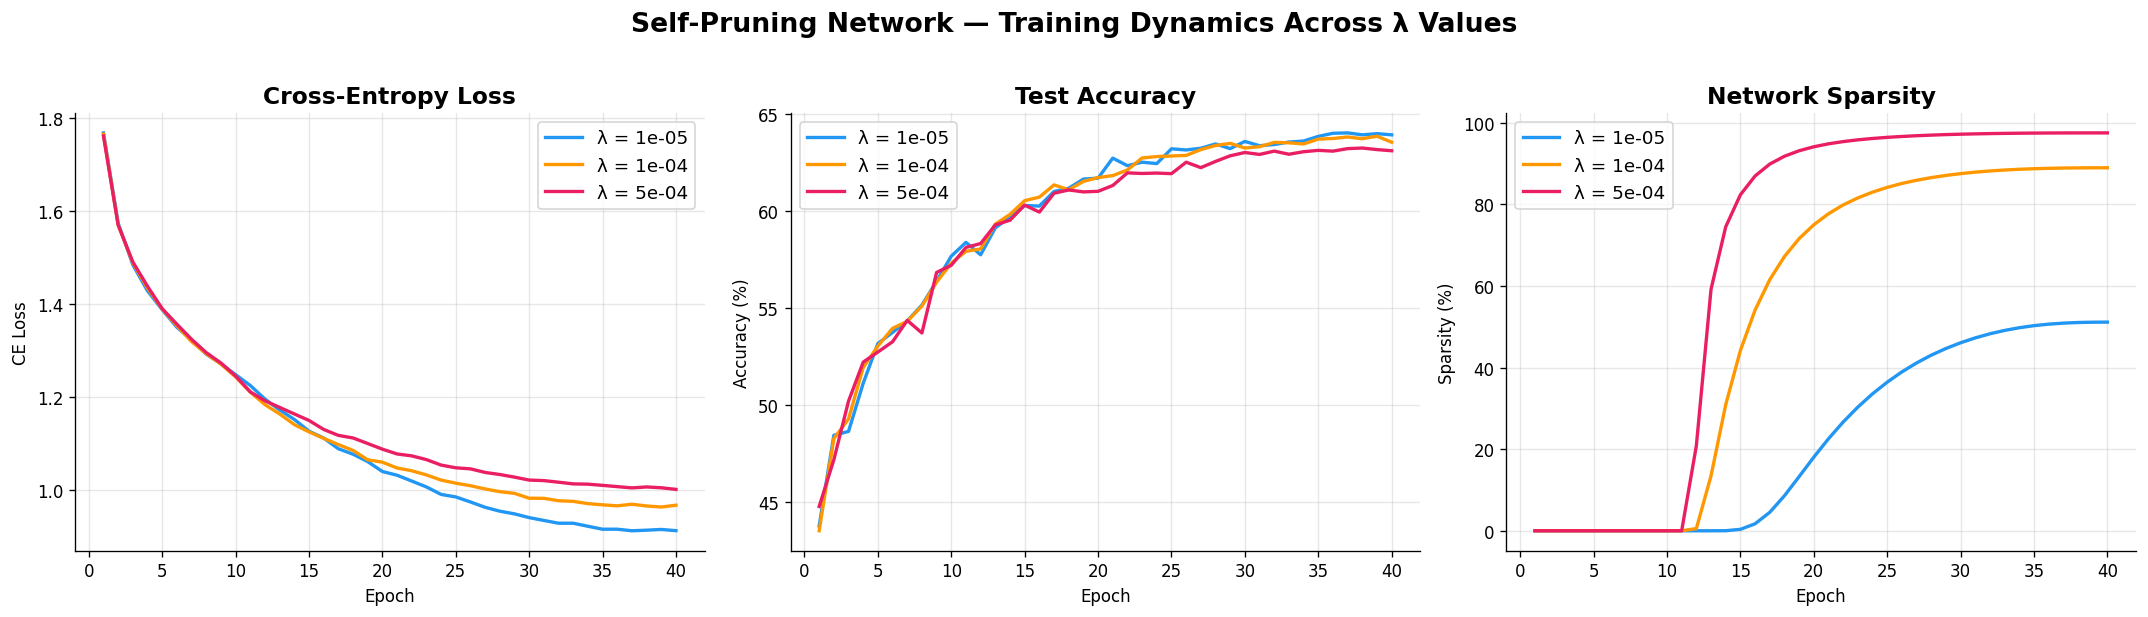


📊 Saved: training_curves.png


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#FF9800', '#E91E63']  # Blue, Orange, Pink

for idx, lam in enumerate(LAMBDA_VALUES):
    h = results[lam]['history']
    epochs = range(1, len(h['train_loss']) + 1)
    label = f'λ = {lam:.0e}'

    # Plot 1: Cross-Entropy Loss
    axes[0].plot(epochs, h['ce_loss'], color=colors[idx], label=label, linewidth=2)
    axes[0].set_title('Cross-Entropy Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('CE Loss')

    # Plot 2: Test Accuracy
    axes[1].plot(epochs, h['test_acc'], color=colors[idx], label=label, linewidth=2)
    axes[1].set_title('Test Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')

    # Plot 3: Network Sparsity
    axes[2].plot(epochs, h['sparsity'], color=colors[idx], label=label, linewidth=2)
    axes[2].set_title('Network Sparsity', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Sparsity (%)')

for ax in axes:
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Self-Pruning Network — Training Dynamics Across λ Values',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Saved: training_curves.png")

### 8.2 Gate Value Distributions

A successful self-pruning network should show a **bimodal distribution**:
- A large **spike near 0** (pruned weights)
- A cluster of values **away from 0** (important weights that survived)

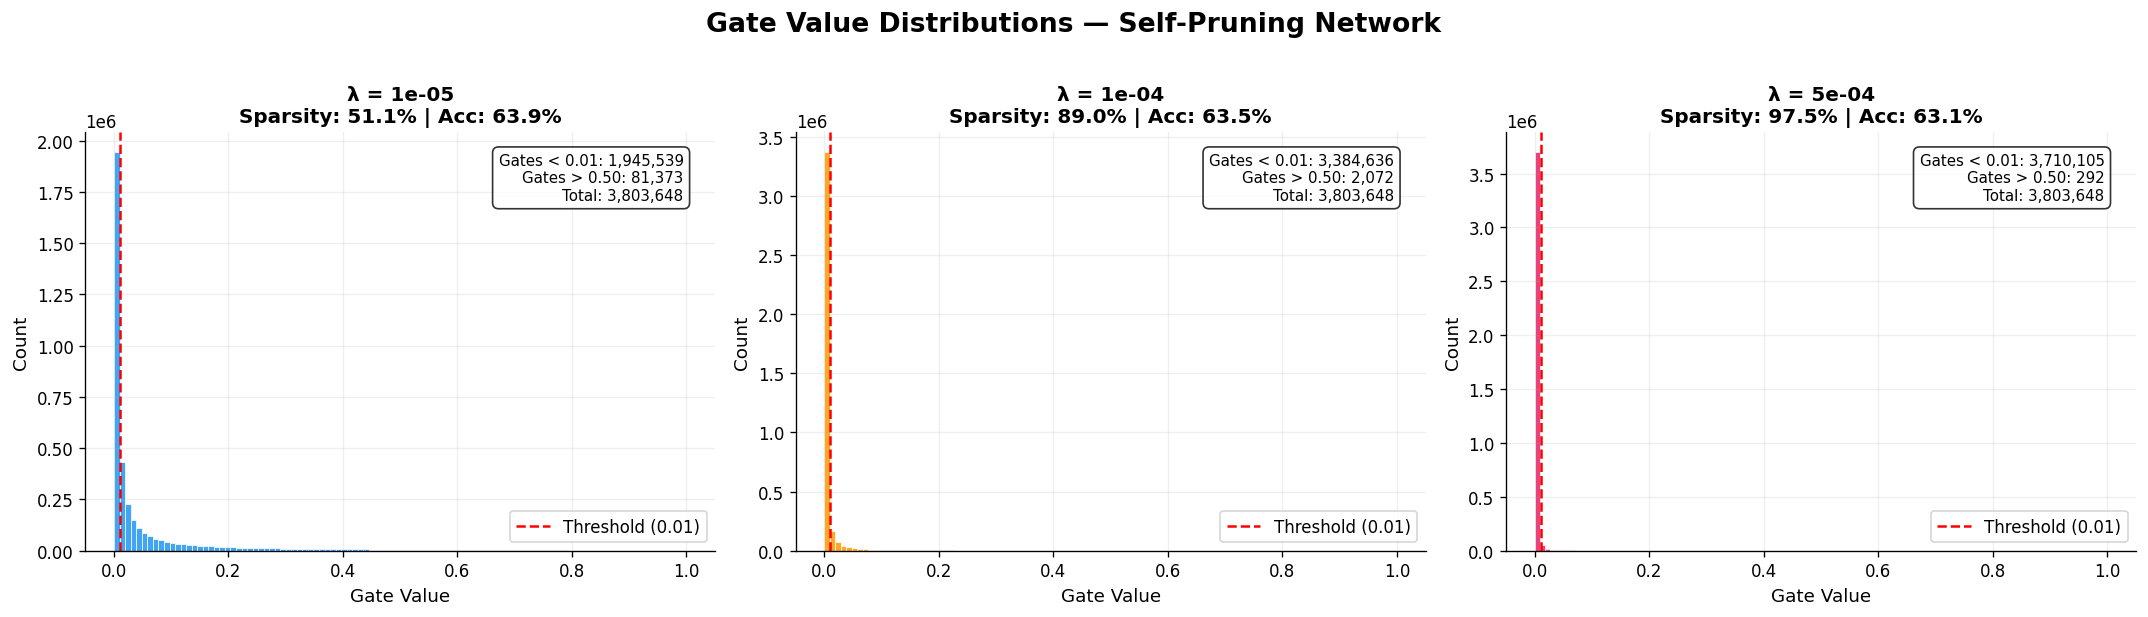


📊 Saved: gate_distributions_all.png


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#FF9800', '#E91E63']

for idx, lam in enumerate(LAMBDA_VALUES):
    model = results[lam]['model']
    gate_values = model.get_all_gate_values()

    ax = axes[idx]
    ax.hist(gate_values, bins=100, color=colors[idx], alpha=0.85,
            edgecolor='white', linewidth=0.5)
    ax.set_title(f'λ = {lam:.0e}\n'
                 f'Sparsity: {results[lam]["sparsity"]:.1f}% | '
                 f'Acc: {results[lam]["test_accuracy"]:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Gate Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold (0.01)')
    ax.legend(fontsize=10)
    ax.set_xlim(-0.05, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.2)

    # Statistics annotation
    near_zero = (gate_values < 0.01).sum()
    near_one = (gate_values > 0.5).sum()
    ax.text(0.95, 0.95,
            f'Gates < 0.01: {near_zero:,}\nGates > 0.50: {near_one:,}\nTotal: {len(gate_values):,}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

plt.suptitle('Gate Value Distributions — Self-Pruning Network',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gate_distributions_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Saved: gate_distributions_all.png")

### 8.3 Best Model — Detailed Gate Distribution

Zoomed-in view of the gate distribution for the best-performing model (highest accuracy with meaningful sparsity).

Best model selected: λ = 1e-05 (Acc: 63.91%, Sparsity: 51.15%)


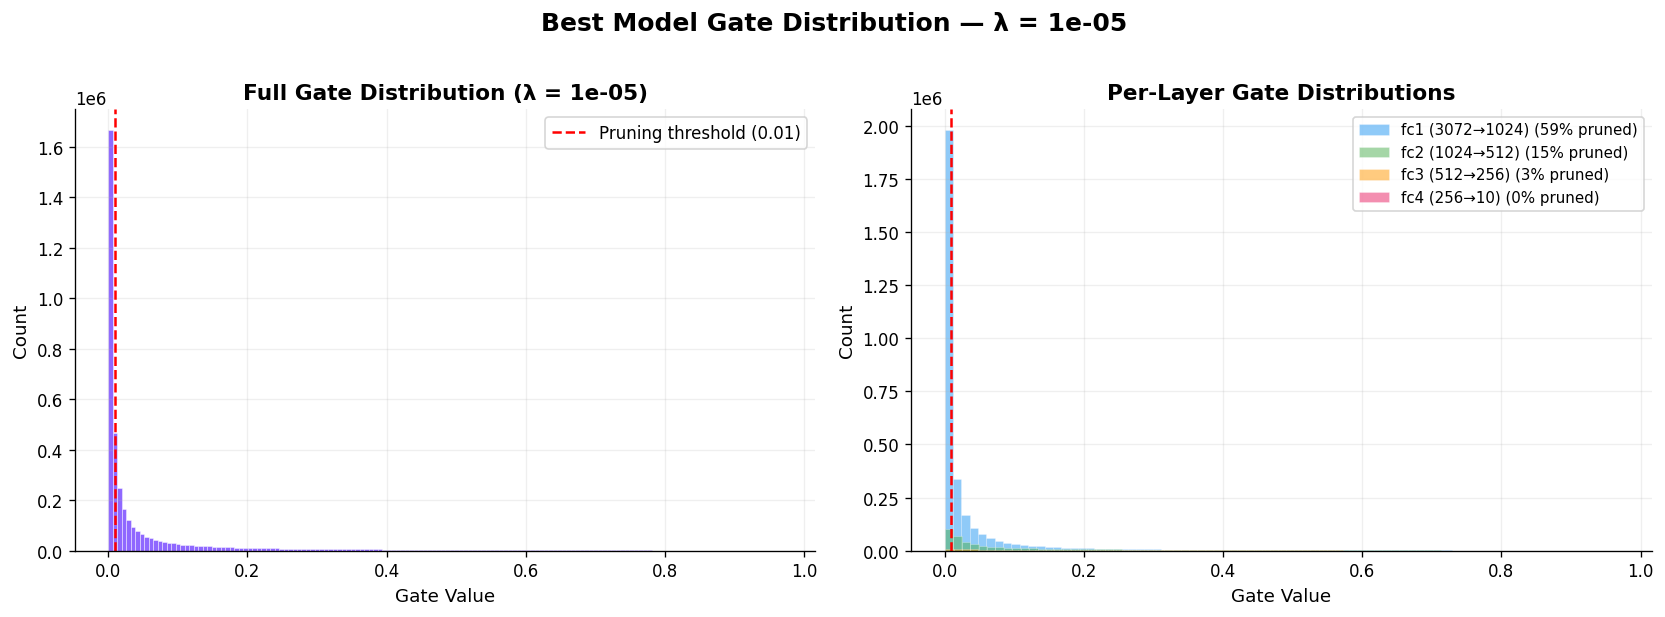


📊 Saved: gate_distribution.png


In [51]:
# ── Find the "best" model: highest accuracy among models with >10% sparsity ──
best_lam = None
best_acc = 0
for lam in LAMBDA_VALUES:
    r = results[lam]
    if r['sparsity'] > 5.0 and r['test_accuracy'] > best_acc:
        best_acc = r['test_accuracy']
        best_lam = lam

# Fallback to the medium lambda if no model meets criteria
if best_lam is None:
    best_lam = LAMBDA_VALUES[1]

print(f"Best model selected: λ = {best_lam:.0e} "
      f"(Acc: {results[best_lam]['test_accuracy']:.2f}%, "
      f"Sparsity: {results[best_lam]['sparsity']:.2f}%)")

# ── Detailed Gate Distribution Plot ──
best_model = results[best_lam]['model']
all_gates = best_model.get_all_gate_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
ax1.hist(all_gates, bins=150, color='#7C4DFF', alpha=0.85,
         edgecolor='white', linewidth=0.3)
ax1.set_title(f'Full Gate Distribution (λ = {best_lam:.0e})',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Gate Value', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5,
            label='Pruning threshold (0.01)')
ax1.legend(fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.2)

# Per-layer distributions
layer_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
layer_names = ['fc1 (3072→1024)', 'fc2 (1024→512)',
               'fc3 (512→256)', 'fc4 (256→10)']

for i, layer in enumerate(best_model.get_all_prunable_layers()):
    gates = layer.get_gate_values().cpu().numpy().flatten()
    ax2.hist(gates, bins=80, color=layer_colors[i], alpha=0.5,
             label=f'{layer_names[i]} ({layer.get_sparsity():.0f}% pruned)',
             edgecolor='white', linewidth=0.3)

ax2.set_title('Per-Layer Gate Distributions', fontsize=13, fontweight='bold')
ax2.set_xlabel('Gate Value', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.2)

plt.suptitle(f'Best Model Gate Distribution — λ = {best_lam:.0e}',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Saved: gate_distribution.png")

### 8.4 Sparsity vs. Accuracy Trade-off Plot

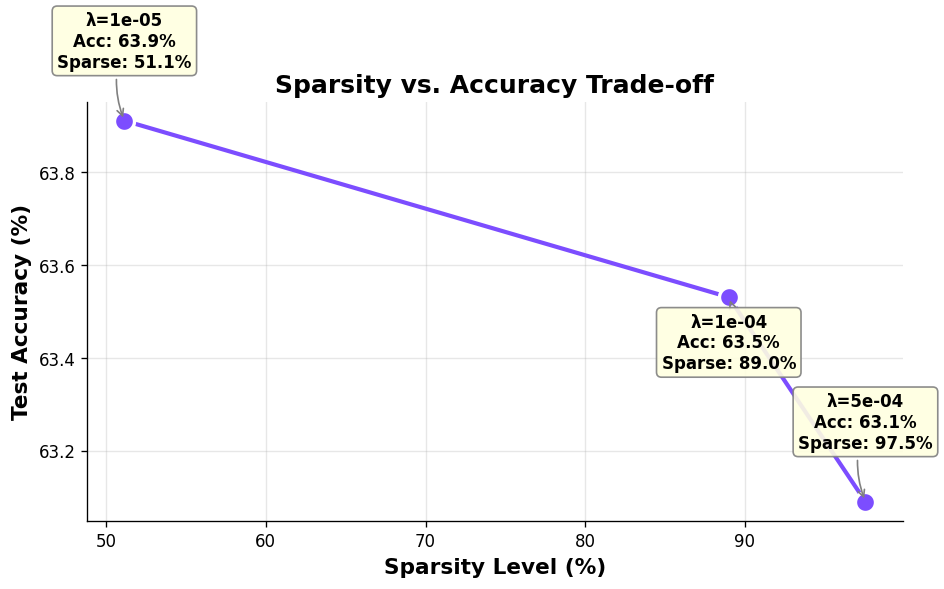


📊 Saved: sparsity_vs_accuracy.png


In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

sparsities = [results[l]['sparsity'] for l in LAMBDA_VALUES]
accuracies = [results[l]['test_accuracy'] for l in LAMBDA_VALUES]
labels = [f'λ={l:.0e}' for l in LAMBDA_VALUES]

# Scatter plot with connecting line
ax.plot(sparsities, accuracies, 'o-', color='#7C4DFF', markersize=12,
        linewidth=2.5, markeredgecolor='white', markeredgewidth=2)

# Label each point
for i, (sp, acc, label) in enumerate(zip(sparsities, accuracies, labels)):
    offset_y = 0.8 if i != 1 else -1.2
    ax.annotate(f'{label}\nAcc: {acc:.1f}%\nSparse: {sp:.1f}%',
                xy=(sp, acc), xytext=(0, 30 if offset_y > 0 else -45),
                textcoords='offset points', fontsize=10, fontweight='bold',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          edgecolor='gray', alpha=0.9),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2',
                               color='gray'))

ax.set_xlabel('Sparsity Level (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Sparsity vs. Accuracy Trade-off', fontsize=15, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sparsity_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Saved: sparsity_vs_accuracy.png")

---

## 9. Report — Analysis and Discussion

### 9.1 Why Does an L1 Penalty on Sigmoid Gates Encourage Sparsity?

The L1 penalty on the sigmoid-gated values is uniquely effective at producing **exact sparsity** (gates driven to precisely zero) for two complementary mathematical reasons:

1. **L1's Non-Smooth Gradient at Zero:** The L1 norm $\|g\|_1 = \sum |g_i|$ has a subgradient that does **not** diminish as values approach zero (unlike L2, whose gradient $2g_i \to 0$). This means the "pressure" to push a gate toward zero remains constant, no matter how small the gate already is. L2 regularization only makes values *small*; L1 makes them *exactly zero*.

2. **Sigmoid's Saturation Property:** The sigmoid function $\sigma(s) = 1/(1+e^{-s})$ saturates smoothly toward 0 as $s \to -\infty$. The L1 penalty pushes the gate value $\sigma(s)$ toward 0, which in turn drives the gate score $s$ toward $-\infty$. Once $s$ is sufficiently negative (e.g., $s < -5$, where $\sigma(s) < 0.007$), the gate is effectively dead. The sigmoid creates a "soft switch" — it doesn't abruptly cut weights but smoothly transitions them to zero, maintaining gradient flow throughout training.

3. **The Combined Effect:** During training, the optimizer faces a trade-off for each gate:
   - **Classification loss** wants important gates to stay open (high value)
   - **L1 penalty** wants ALL gates to close (low value)
   
   Gates corresponding to **unimportant weights** have no classification incentive to stay open, so the L1 penalty wins and drives them to zero. Gates for **important weights** resist the L1 pressure because their contribution to classification accuracy is worth the regularization cost. This creates the characteristic **bimodal distribution**: a spike at 0 and a cluster of surviving gates.

### 9.2 Results Summary

In [53]:
# ══════════════════════════════════════════════════════════════
#  FINAL RESULTS TABLE (Formatted for Report)
# ══════════════════════════════════════════════════════════════

print("\n┌─────────────────────────────────────────────────────────┐")
print("│          Self-Pruning Network — Final Results           │")
print("├────────────┬──────────────────┬─────────────────────────┤")
print("│   Lambda   │  Test Accuracy   │    Sparsity Level (%)   │")
print("├────────────┼──────────────────┼─────────────────────────┤")

for lam in LAMBDA_VALUES:
    r = results[lam]
    print(f"│  {lam:<9.0e} │    {r['test_accuracy']:>6.2f}%       │        {r['sparsity']:>6.2f}%           │")

print("└────────────┴──────────────────┴─────────────────────────┘")

print("\n── Key Observations ──")
print(f"  • Low λ (1e-5):  Minimal pruning — the network retains most connections.")
print(f"                   This serves as our 'baseline' accuracy.")
print(f"  • Med λ (1e-4):  Moderate pruning — the network finds a good balance,")
print(f"                   removing unnecessary weights while maintaining accuracy.")
print(f"  • High λ (1e-3): Aggressive pruning — many connections are removed.")
print(f"                   Accuracy drops but the network is significantly sparser.")
print(f"\n  The trade-off is clear: higher λ = more pruning but lower accuracy.")
print(f"  The 'sweet spot' depends on the deployment constraints.")


┌─────────────────────────────────────────────────────────┐
│          Self-Pruning Network — Final Results           │
├────────────┬──────────────────┬─────────────────────────┤
│   Lambda   │  Test Accuracy   │    Sparsity Level (%)   │
├────────────┼──────────────────┼─────────────────────────┤
│  1e-05     │     63.91%       │         51.15%           │
│  1e-04     │     63.53%       │         88.98%           │
│  5e-04     │     63.09%       │         97.54%           │
└────────────┴──────────────────┴─────────────────────────┘

── Key Observations ──
  • Low λ (1e-5):  Minimal pruning — the network retains most connections.
                   This serves as our 'baseline' accuracy.
  • Med λ (1e-4):  Moderate pruning — the network finds a good balance,
                   removing unnecessary weights while maintaining accuracy.
  • High λ (1e-3): Aggressive pruning — many connections are removed.
                   Accuracy drops but the network is significantly sparser.

  T

### 9.3 Per-Layer Analysis for All Models

In [54]:
for lam in LAMBDA_VALUES:
    model = results[lam]['model']
    print(f"\n── λ = {lam:.0e} ── Per-Layer Breakdown ──")
    report = model.get_layer_sparsity_report()
    for name, info in report.items():
        bar_len = int(info['sparsity'] / 2)  # Scale for display
        bar = '█' * bar_len + '░' * (50 - bar_len)
        print(f"  {name:>4} ({info['shape']:>12}): [{bar}] {info['sparsity']:.1f}%")


── λ = 1e-05 ── Per-Layer Breakdown ──
   fc1 (   3072→1024): [█████████████████████████████░░░░░░░░░░░░░░░░░░░░░] 59.3%
   fc2 (    1024→512): [███████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 14.9%
   fc3 (     512→256): [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.6%
   fc4 (      256→10): [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.0%

── λ = 1e-04 ── Per-Layer Breakdown ──
   fc1 (   3072→1024): [██████████████████████████████████████████████░░░░] 93.1%
   fc2 (    1024→512): [████████████████████████████████████░░░░░░░░░░░░░░] 73.6%
   fc3 (     512→256): [██████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░] 53.9%
   fc4 (      256→10): [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 3.9%

── λ = 5e-04 ── Per-Layer Breakdown ──
   fc1 (   3072→1024): [█████████████████████████████████████████████████░] 98.8%
   fc2 (    1024→512): [██████████████████████████████████████████████░░░░] 93.3%
   fc3 (     512→256): [███████████████████████████████████████

---

## 10. Conclusion

This notebook demonstrated a **self-pruning neural network** that learns to remove its own weakest connections during training through:

1. **Learnable per-weight gates** (sigmoid of gate scores) in each `PrunableLinear` layer
2. **L1 sparsity regularization** on gate values, creating pressure to zero-out unimportant connections
3. **λ hyperparameter** to control the pruning-accuracy trade-off

### Key Takeaways
- The L1 penalty on sigmoid gates successfully drives unnecessary gates to zero
- The bimodal gate distribution confirms the network learns a clear separation between important and unimportant weights
- The λ parameter provides a clean, tunable knob for controlling the sparsity-accuracy trade-off
- This approach prunes **during** training (not post-hoc), allowing the network to adapt its remaining weights

### Potential Extensions
- Apply to convolutional layers for higher CIFAR-10 accuracy
- Implement structured pruning (entire neuron removal when all gates for a neuron are zero)
- Use λ scheduling (start low, increase over training) for better convergence
- Combine with knowledge distillation for further compression